In [ ]:
import numpy as np
from qutip import sigmap, sigmam, tensor, qeye, Qobj
from qutip import kraus_to_super, to_super, operator_to_vector, vector_to_operator, fidelity, basis
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from qutip import rand_unitary

In [58]:
def rho_sys_anc(g,t,rho):
  sigma_plus = sigmap()
  sigma_minus = sigmam()
  
  rho_anc = np.array ([[1.0,0.0],[0.0,0.0]])
  rho = Qobj(rho)
  rho_anc = Qobj(rho_anc)
  rho_sys_anc_pro = tensor(rho,rho_anc)
  
  H = g*(tensor(sigma_plus,sigma_minus) + tensor(sigma_minus,sigma_plus))
  Uni_sa = (-1j * H * t).expm()

  display(Uni_sa)

  # Uni_sa = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]])
  Uni_sa = Qobj(Uni_sa, dims=[[2,2],[2,2]])
  rho_sa = Uni_sa * rho_sys_anc_pro * Uni_sa.dag()

  k0 = Qobj(np.array([[Uni_sa[0,0],Uni_sa[0,2]],[Uni_sa[2,0], Uni_sa[2,2]]]))
  k1 = Qobj(np.array([[Uni_sa[1,0],Uni_sa[1,2]],[Uni_sa[3,0], Uni_sa[3,2]]]))

  u_super = kraus_to_super([k0,k1])
  

  return rho_sa , u_super

def noisey_joint_state_gen(U, rho_sa):
  
  U = Qobj(U.full(), dims=[[2,2],[2,2]])
  
  ket0 = basis(2,0)
  ket1 = basis(2,1)
  p = 0.5


  K00 = np.sqrt(p) * (
    tensor(qeye(2), ket0.dag())
    * U
    * tensor(qeye(2), ket0)
  )
  
  K10 = np.sqrt(p) * (
    tensor(qeye(2), ket1.dag())
    * U
    * tensor(qeye(2), ket0)
  )
  
  K01 = np.sqrt(1-p) * (
    tensor(qeye(2), ket0.dag())
    * U
    * tensor(qeye(2), ket1)
  )
  
  K11 = np.sqrt(1-p) * (
    tensor(qeye(2), ket1.dag())
    * U
    * tensor(qeye(2), ket1)
  )

  K1 = Qobj(K00.full(), dims=[[2],[2]])
  K2 = Qobj(K10.full(), dims=[[2],[2]])
  K3 = Qobj(K01.full(), dims=[[2],[2]])
  K4 = Qobj(K11.full(), dims=[[2],[2]])

  A1 = tensor(K1, Id)
  A2 = tensor(K2, Id)
  A3 = tensor(K3, Id)
  A4 = tensor(K4, Id)
  

  rho_sa_noisy_gen = (
    A1 * rho_sa * A1.dag() +
    A2 * rho_sa * A2.dag() +
    A3 * rho_sa * A3.dag() +
    A4 * rho_sa * A4.dag()
      
  )


  noise_super_gen = kraus_to_super([K1,K2,K3,K4])
  
  
  return rho_sa_noisy_gen, noise_super_gen
  

   





#amplitude damping noise
def noisey_joint_state_amp(gamma, rho_sa):
    Id = qeye(2)
    K1 = np.array([[1, 0],
               [0, np.sqrt(1 - gamma)]])

    K2 = np.array([[0, np.sqrt(gamma)],
               [0, 0]])


   
    K1 = Qobj(K1)
    K2 = Qobj(K2)

    A1 = tensor(K1, Id)
    A2 = tensor(K2, Id)

    rho_sa_noisy_amp = (
        A1 * rho_sa * A1.dag() +
        A2 * rho_sa * A2.dag()
    )


    noise_super_amp = kraus_to_super([K1,K2])
   
   
    return rho_sa_noisy_amp, noise_super_amp

#Dephasing noise
def noisey_joint_state_dph(gamma, rho_sa):
    Id = qeye(2)
    K0 = np.sqrt(1-gamma)*qeye(2)
    K1 = np.array([[np.sqrt(gamma), 0],
               [0, 0]])

    K2 = np.array([[0, 0],
               [0, np.sqrt(gamma)]])

    # K0 = (1/np.sqrt(3))* qeye(2)
    # K1 = (1/np.sqrt(3))* qeye(2)
    # K2 = (1/np.sqrt(3))* qeye(2)
   
    K0 = Qobj(K0)
    K1 = Qobj(K1)
    K2 = Qobj(K2)

    A0 = tensor(K0, Id)
    A1 = tensor(K1, Id)
    A2 = tensor(K2, Id)

    rho_sa_noisy_dph = (
        A0 * rho_sa * A0.dag() +
        A1 * rho_sa * A1.dag() +
        A2 * rho_sa * A2.dag()
    )


    
    noise_super_dph = kraus_to_super([K1, K2])

    return rho_sa_noisy_dph, noise_super_dph

def noisey_joint_state_bitflip(gamma, rho_sa):
    I = np.array([[1, 0],
                  [0, 1]], dtype=complex)
   
    X = np.array([[0, 1],
                  [1, 0]], dtype=complex)
   
    K1 = np.sqrt(1 - gamma) * I
    K2 = np.sqrt(gamma) * X

   
    K1 = Qobj(K1)
    K2 = Qobj(K2)

    A1 = tensor(K1, Id)
    A2 = tensor(K2, Id)

    rho_sa_noisy_dph = (
        A1 * rho_sa * A1.dag() +
        A2 * rho_sa * A2.dag()
    )

    K1 = np.array([[1, 0],
               [0, np.sqrt(1 - gamma)]])

    K2 = np.array([[0, np.sqrt(gamma)],
               [0, 0]])

    K1 = Qobj(K1)
    K2 = Qobj(K2)

    A1 = tensor(K1, Id)
    A2 = tensor(K2, Id)

    rho_sa_noisy_dph = (
        A1 * rho_sa * A1.dag() +
        A2 * rho_sa * A2.dag()
    )
    noise_super_dph = kraus_to_super([K1, K2])

    return rho_sa_noisy_dph, noise_super_dph

def povm_ele(rho1,rho2,q1,q2):
    M = q1*rho1 - q2*rho2
    M = Qobj(M)
    eigvals, eigvecs = M.eigenstates()
    # M_spectral = sum(eigvals[i] * eigvecs[i] * eigvecs[i].dag() for i in range(len(eigvals)))
    # eigvals_spe,eigvecs_spe = M_spectral.eigenstates()
   
    # if eigvals_spe[0] > 0:
    if eigvals[0] > eigvals[1]:
        povm_pos = eigvecs[0] * eigvecs[0].dag()
        povm_neg = eigvecs[1] * eigvecs[1].dag()
       
    # elif eigvals_spe[0] < 0:
    else:
        povm_pos = eigvecs[1] * eigvecs[1].dag()
        povm_neg = eigvecs[0] * eigvecs[0].dag()


    return povm_pos,povm_neg


def lambda_complete (rho1, rho2):
    Id = qeye(2)
    rho1 = Qobj(rho1)
    rho2 = Qobj(rho2)
   
   
    e1,evec1 = rho1.eigenstates()
    e2,evec2 = rho2.eigenstates()
    # print("rho1= ",rho1)
    # print("rho2= ", rho2)

    ket0 = basis(2, 0)
    ket1 = basis(2, 1)
    bra0 = ket0.dag()
    bra1 = ket1.dag()

    U2 = evec2[0] * bra0 + evec2[1] * bra1
    U1 = ket0 * evec1[0].dag() + ket1 * evec1[1].dag()
    if np.isclose(e1[0], e2[0]):
        k0 = Qobj(Id/np.sqrt(2))
        k1 = Qobj(Id/np.sqrt(2))
    # if e1[0] == e2[0]:
    #     k0 = Qobj(0.5 * Id)
    #     k1 =Qobj( 0.5 * Id)
       
    elif e1[0] < e2[0]:
        k0 = Qobj(np.array([[np.sqrt(e1[0]/e2[0]), 0],[0, 1]]))
        k1 = Qobj(np.array([[0, 0],[np.sqrt(1-(e1[0]/e2[0])), 0]]))
    elif e1[1] < e2[1]:
        k0 = Qobj(np.array([[1, 0],[0, np.sqrt(e1[1]/e2[1])]]))
        k1 = Qobj(np.array([[0, np.sqrt(1-(e1[1]/e2[1]))],[0, 0]]))
   
    # print(k0)

    s_complete = kraus_to_super([U1 * k0 * U2, U1 * k1 * U2])
   
    return s_complete
   

def recovery_map(rho, rho_out, s_complete, u_super, noise_super_amp, noise_super_dph, joint_super, k):

  rho = Qobj(rho)
  rho_out = Qobj(rho_out)
  rho_sqrt = rho.sqrtm()

  if k == 1:
      new_super = s_complete * noise_super_amp * u_super
  if k == 2:
      new_super = s_complete * noise_super_dph * u_super

  joint_super = new_super * joint_super
  # joint_super = new_super
  joint_super_dag = joint_super.dag()

  rho_vec = operator_to_vector(rho)

  final_rho_vec = joint_super * rho_vec  #total CPTP operation on the input state rho

  final_rho = vector_to_operator(final_rho_vec)

  
  final_rho_sqrt = final_rho.sqrtm()
  final_rho_sqrt_inverse = final_rho.sqrtm().inv()
  
  final_rho_sqrt = Qobj(final_rho_sqrt)
  final_rho_sqrt_inverse = Qobj(final_rho_sqrt_inverse)
  

  middle_part = final_rho_sqrt_inverse * rho_out * final_rho_sqrt_inverse

  middle_part_vec = operator_to_vector(middle_part)

  total_middle_vec = joint_super_dag * middle_part_vec
  total_middle  = vector_to_operator(total_middle_vec)

  rho_reco = rho_sqrt * total_middle * rho_sqrt

  
  return rho_reco, joint_super



def petz(rho,rho_out,u_super,noise_super_amp):

  rho = Qobj(rho)
  rho_out = Qobj(rho_out)
  rho_sqrt = rho.sqrtm()

  rho_vec = operator_to_vector(rho)
  N_sigma_vec = noise_super_amp * u_super * rho_vec
  N_sigma_op = vector_to_operator(N_sigma_vec)
  N_sigma_op_sqrt_inv = N_sigma_op.sqrtm().inv()

  middle = N_sigma_op_sqrt_inv * rho_out * N_sigma_op_sqrt_inv
  dag_map = (noise_super_amp * u_super).dag()
  middle_vec = operator_to_vector(middle)
  middle_1 = dag_map * middle_vec

  middle_1_op = vector_to_operator(middle_1)


  rho_reco = rho_sqrt * middle_1_op * rho_sqrt

  return rho_reco
   

def free_evo(rho, rho_target, U):
   
  rho = Qobj(rho)
  gamma = 0.5
  rho_target = Qobj(rho_target)



  U = Qobj(U.full(), dims=[[2,2],[2,2]])
  
  ket0 = basis(2,0)
  ket1 = basis(2,1)

  p = 0.5


  K00 = np.sqrt(p) * (
  tensor(qeye(2), ket0.dag())
  * U
  * tensor(qeye(2), ket0)
  )
  
  K10 = np.sqrt(p) * (
      tensor(qeye(2), ket1.dag())
      * U
      * tensor(qeye(2), ket0)
  )
  
  K01 = np.sqrt(1-p) * (
      tensor(qeye(2), ket0.dag())
      * U
      * tensor(qeye(2), ket1)
  )
  
  K11 = np.sqrt(1-p) * (
      tensor(qeye(2), ket1.dag())
      * U
      * tensor(qeye(2), ket1)
  )


  
  # K1 = tensor(qeye(2), ket0.dag()) * U * tensor(qeye(2), ket0)
  
  # K2 = tensor(qeye(2), ket1.dag()) * U * tensor(qeye(2), ket0)

  K1 = Qobj(K00.full(), dims=[[2],[2]])
  K2 = Qobj(K10.full(), dims=[[2],[2]])
  K3 = Qobj(K01.full(), dims=[[2],[2]])
  K4 = Qobj(K11.full(), dims=[[2],[2]])


  # K1 = np.array([[1, 0],
  #            [0, np.sqrt(1 - gamma)]])

  # K2 = np.array([[0, np.sqrt(gamma)],
  #            [0, 0]])

  # I = np.array([[1, 0],
  #               [0, 1]], dtype=complex)
  
  # X = np.array([[0, 1],
  #               [1, 0]], dtype=complex)
  
  # K1 = np.sqrt(1 - gamma) * I
  # K2 = np.sqrt(gamma) * X
  # K1 = Qobj(K1)
  # K2 = Qobj(K2)

  rho_evo = Qobj(
      
      K1 * rho * K1.dag() +
      K2 * rho * K2.dag() +
      K3 * rho * K3.dag() +
      K4 * rho * K4.dag()
  )


  # K0 = np.sqrt(1-gamma)*qeye(2)
  # K1 = np.array([[np.sqrt(gamma), 0],
  #            [0, 0]])

  # K2 = np.array([[0, 0],
  #            [0, np.sqrt(gamma)]])
  # K0 = Qobj(K0)
  # K1 = Qobj(K1)
  # K2 = Qobj(K2)

  # A0 = tensor(K0, Id)
  # A1 = tensor(K1, Id)
  # A2 = tensor(K2, Id)

  # rho_evo = (
  #     K0 * rho * K0.dag() +
  #     K1 * rho * K1.dag() +
  #     K2 * rho * K2.dag()
  # )

  f = fidelity(rho_evo,rho_target)
  return f, rho_evo
   

In [ ]:
#First system then ancilla always


# Pauli matrices
sx = np.array([[0,1],[1,0]])
sy = np.array([[0,-1j],[1j,0]])
sz = np.array([[1,0],[0,-1]])

zero = np.array ([[1,0],[0,0]]) #|0><0| state
one = np.array ([[0,0],[0,1]])  #|1><1| state


#Initial state that we need to recover
rx, ry, rz = np.sqrt(0.2), np.sqrt(0.2), np.sqrt(0.5)
# rx = np.sqrt(3)/2
# ry = 0.0
# rz = -0.5
rho_target = 0.5 * Qobj(np.array([
  [1 + rz       , rx - 1j * ry],
  [rx + 1j * ry , 1 - rz      ]
]))
print("rho_target")
display(rho_target)

Id = qeye(2)
gamma = 0.5 # keep it < 0 
# gamma_t = 1 - np.exp(-t_steps/T)
g = 1.0
# t = np.pi/4.0
t = 0.1*np.pi
q1 = 0.2
q2 = 0.8
count_1 = 0
count_2 = 0
joint_super = to_super(qeye(2))
U = rand_unitary(4, seed=10)
display(U)


rho_target


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.85355339+0.j        0.2236068 -0.2236068j]
 [0.2236068 +0.2236068j 0.14644661+0.j       ]]

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.35781421-0.53330417j  0.06803502+0.39206035j -0.55787436-0.14879186j
   0.29973453+0.07753678j]
 [-0.33412366-0.63367673j  0.03947738-0.23016077j  0.63189767+0.12867918j
   0.03745059-0.12258548j]
 [ 0.15660851-0.14856193j -0.04278913-0.61617195j -0.36363244-0.23894978j
   0.10075271-0.61026854j]
 [ 0.12591907-0.10917119j  0.48472716+0.41312016j  0.07407338-0.23658355j
  -0.5610232 -0.43633895j]]

In [62]:
g

1.0

In [60]:
fid, rho_evo = free_evo(rho_target, rho_target, U)
print(fid)

rho_sa, u_super = rho_sys_anc(g,t,rho_target)

display(u_super)
display(rho_sa)

0.8498848575934281


Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.95105652+0.j         0.        -0.30901699j
  0.        +0.j        ]
 [0.        +0.j         0.        -0.30901699j 0.95105652+0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  1.        +0.j        ]]

Quantum object: dims=[[[2], [2]], [[2], [2]]], shape=(4, 4), type='super', dtype=Dense, isherm=False
Qobj data =
[[1.         0.         0.         0.0954915 ]
 [0.         0.95105652 0.         0.        ]
 [0.         0.         0.95105652 0.        ]
 [0.         0.         0.         0.9045085 ]]

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.85355339+0.j         0.0690983 +0.0690983j  0.2126627 -0.2126627j
  0.        +0.j        ]
 [0.0690983 -0.0690983j  0.01398441+0.j         0.        -0.04303958j
  0.        +0.j        ]
 [0.2126627 +0.2126627j  0.        +0.04303958j 0.1324622 +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]]

In [63]:
rho_sa_noisy_amp, noise_super_amp = noisey_joint_state_amp(gamma, rho_sa)
rho_sa_noisy_btfp, noise_super_btfp = noisey_joint_state_bitflip(gamma, rho_sa) # I need this just to create the ensemble

rho_noisy_amp_sys = rho_sa_noisy_amp.ptrace(0)

rho_noisy_amp_sys_wo_reco = rho_noisy_amp_sys
F_wo_rec = fidelity(rho_noisy_amp_sys_wo_reco, rho_target)



In [65]:
display(noise_super_amp)
display(rho_sa_noisy_amp)

Quantum object: dims=[[[2], [2]], [[2], [2]]], shape=(4, 4), type='super', dtype=Dense, isherm=False
Qobj data =
[[1.         0.         0.         0.5       ]
 [0.         0.70710678 0.         0.        ]
 [0.         0.         0.70710678 0.        ]
 [0.         0.         0.         0.5       ]]

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.91978449+0.j         0.0690983 +0.0690983j  0.15037524-0.15037524j
  0.        +0.j        ]
 [0.0690983 -0.0690983j  0.01398441+0.j         0.        -0.03043358j
  0.        +0.j        ]
 [0.15037524+0.15037524j 0.        +0.03043358j 0.0662311 +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]]

In [ ]:

# rho_final = petz(rho, rho_noisy_amp_sys, u_super, noise_super_amp)

# F = fidelity(rho_final, rho_target)
# rho = rho_final

rho_noisy_dph_sys = rho_sa_noisy_btfp.ptrace(0)
ele_pos, ele_neg = povm_ele(rho_noisy_amp_sys,rho_noisy_dph_sys,q1,q2)
ele_pos = Qobj (ele_pos)
ele_neg = Qobj (ele_neg)
rho_noisy_amp_sys = Qobj(rho_noisy_amp_sys)
# print(ele_pos + ele_neg)

#post measurement state for the discrimination

rho_sa_mea_1 = (tensor(Id,ele_pos) * rho_sa_noisy_amp * (tensor(Id,ele_pos)).dag())/ ((tensor(Id,ele_pos) * rho_sa_noisy_amp * (tensor(Id,ele_pos)).dag())).tr()
#post measurent system_ancilla state output rho_sa_noisy_amp
prob1 = ((tensor(Id,ele_pos) * rho_sa_noisy_amp * (tensor(Id,ele_pos)).dag())).tr()



rho_sa_mea_2 = (tensor(Id,ele_neg)* rho_sa_noisy_amp * (tensor(Id,ele_neg)).dag()) / ((tensor(Id,ele_neg)* rho_sa_noisy_amp * (tensor(Id,ele_neg)).dag())).tr()
#post measurent system_ancilla state output 2
prob2 = ((tensor(Id,ele_neg)* rho_sa_noisy_amp * (tensor(Id,ele_neg)).dag())).tr()

# prob1 = np.real_if_close(prob1)
# prob2 = np.real_if_close(prob2)
# print(prob1, prob2)


#simulating the measurement result

outcome = np.random.choice([1, 2], p=[prob1, prob2])
# print(outcome)
# if outcome == 1:
#     print("correct recovery for turn i = ", i)

if outcome == 1:
  rho_out = rho_sa_mea_1.ptrace(0)
  s_complete = lambda_complete(rho_noisy_amp_sys, rho_out)
  count_1 = count_1 + 1
elif outcome == 2:
  rho_out = rho_sa_mea_2.ptrace(0)
  s_complete = lambda_complete(rho_noisy_amp_sys, rho_out)
  count_2 = count_2 + 1
# print(rho_out.tr())
# print (outcome)


#Now, we have to apply the petz recovery map on this "rho_out" state according to the count. Apply the function recovery_map() to get the
# recovered rho an then we will take the trace with original rho

if count_1 > count_2 or 10*(count_1 - count_2) == outcome - 2:
  k = 1
  # print("correct")
  
elif count_1 < count_2 or 10*(count_1 - count_2) == outcome - 1:
  k = 2
  # print("incorrect")


rho_final, joint_super =  recovery_map(rho_target, rho_out, s_complete, u_super, noise_super_amp, noise_super_btfp, joint_super, k)

# print( "i=", i, rho_final.tr())
# print("count_1 = ", count_1, "    " , "count_2=", count_2)
# print(i, "   ","rho_final",  rho_final)
F = fidelity(rho_final, rho_target)
rho = rho_final

In [ ]:
x = []
y1 = []
y2 = []
rng = np.random.default_rng(seed=42)
for i in range(1,31):
   
  if i == 1:
      rho = rho_target
      rho_evo = rho_target
  fid, rho_evo = free_evo(rho_evo, rho_target, U)
  print(fid, end="\t|\t")
  
  rho_sa, u_super = rho_sys_anc(g,t,rho)


  rho_sa_noisy_amp, noise_super_amp = noisey_joint_state_amp(gamma, rho_sa)
  rho_sa_noisy_btfp, noise_super_btfp = noisey_joint_state_bitflip(gamma, rho_sa) # I need this just to create the ensemble

  rho_noisy_amp_sys = rho_sa_noisy_amp.ptrace(0)

  rho_noisy_amp_sys_wo_reco = rho_noisy_amp_sys
  F_wo_rec = fidelity(rho_noisy_amp_sys_wo_reco, rho_target)
  

  # rho_final = petz(rho, rho_noisy_amp_sys, u_super, noise_super_amp)

  # F = fidelity(rho_final, rho_target)
  # rho = rho_final

  rho_noisy_dph_sys = rho_sa_noisy_btfp.ptrace(0)
  ele_pos, ele_neg = povm_ele(rho_noisy_amp_sys,rho_noisy_dph_sys,q1,q2)
  ele_pos = Qobj (ele_pos)
  ele_neg = Qobj (ele_neg)
  rho_noisy_amp_sys = Qobj(rho_noisy_amp_sys)
  # print(ele_pos + ele_neg)

  #post measurement state for the discrimination

  rho_sa_mea_1 = (tensor(Id,ele_pos) * rho_sa_noisy_amp * (tensor(Id,ele_pos)).dag())/ ((tensor(Id,ele_pos) * rho_sa_noisy_amp * (tensor(Id,ele_pos)).dag())).tr()
  #post measurent system_ancilla state output rho_sa_noisy_amp
  prob1 = ((tensor(Id,ele_pos) * rho_sa_noisy_amp * (tensor(Id,ele_pos)).dag())).tr()
  


  rho_sa_mea_2 = (tensor(Id,ele_neg)* rho_sa_noisy_amp * (tensor(Id,ele_neg)).dag()) / ((tensor(Id,ele_neg)* rho_sa_noisy_amp * (tensor(Id,ele_neg)).dag())).tr()
  #post measurent system_ancilla state output 2
  prob2 = ((tensor(Id,ele_neg)* rho_sa_noisy_amp * (tensor(Id,ele_neg)).dag())).tr()
  
  # prob1 = np.real_if_close(prob1)
  # prob2 = np.real_if_close(prob2)
  # print(prob1, prob2)
  

  #simulating the measurement result

  outcome = rng.choice([1, 2], p=[prob1, prob2])
  # print(outcome)
  # if outcome == 1:
  #     print("correct recovery for turn i = ", i)
  
  if outcome == 1:
    rho_out = rho_sa_mea_1.ptrace(0)
    s_complete = lambda_complete(rho_noisy_amp_sys, rho_out)
    count_1 = count_1 + 1
  elif outcome == 2:
    rho_out = rho_sa_mea_2.ptrace(0)
    s_complete = lambda_complete(rho_noisy_amp_sys, rho_out)
    count_2 = count_2 + 1
  # print(rho_out.tr())
  # print (outcome)
  
  
  #Now, we have to apply the petz recovery map on this "rho_out" state according to the count. Apply the function recovery_map() to get the
  # recovered rho an then we will take the trace with original rho

  if count_1 > count_2 or 10*(count_1 - count_2) == outcome - 2:
    k = 1
    # print("correct")
    
  elif count_1 < count_2 or 10*(count_1 - count_2) == outcome - 1:
    k = 2
    # print("incorrect")


  rho_final, joint_super =  recovery_map(rho_target, rho_out, s_complete, u_super, noise_super_amp, noise_super_btfp, joint_super, k)

  # print( "i=", i, rho_final.tr())
  # print("count_1 = ", count_1, "    " , "count_2=", count_2)
  # print(i, "   ","rho_final",  rho_final)
  F = fidelity(rho_final, rho_target)
  rho = rho_final
  print(F, end="\t|  ")
  print(outcome)
  
  # print("i", i, "   "   "F = ", F, "F_wo_reco =", fid)
  # print("i", i, "   "   "F = ", F)
  # print(rho)
  # print(rho_target)


  x.append(i)
  y1.append(F)
  y2.append(fid)
   


0.8498848575934281	|	0.9981600841946361	|  2
0.8230172226384436	|	0.9940744384293585	|  2
0.8145577687545387	|	0.9927632838385765	|  2
0.81189737570138	|	0.9948667375935022	|  2
0.8113318010022879	|	0.9970925103562625	|  2
0.8112519382150972	|	0.998458209992268	|  2
0.8112440086530417	|	0.9992028191386971	|  2
0.8112427925673514	|	0.999596727843446	|  2
0.8112423469371963	|	0.9998004012440416	|  2
0.8112422140733537	|	0.9999031665177086	|  2
0.8112421885278402	|	0.9999538253673385	|  2
0.8112421854871872	|	0.9999782921559882	|  2
0.8112421852551305	|	0.9999899084735717	|  2
0.8112421852062514	|	0.9999953486287716	|  2
0.8112421851833501	|	0.9999978696142329	|  2
0.8112421851767926	|	0.9999990286908585	|  2
0.8112421851756751	|	0.9999995585692065	|  2
0.8112421851755716	|	0.9999997998285907	|  2
0.8112421851755672	|	0.999999909368029	|  2
0.8112421851755649	|	0.9999999590065739	|  2
0.8112421851755638	|	0.999999981471213	|  2
0.8112421851755636	|	0.9999999916289647	|  2
0.81124218517556

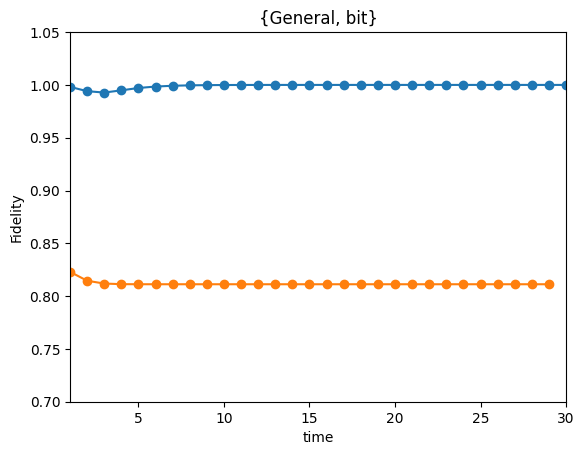

In [55]:
plt.plot(x, y1, y2, marker='o')
plt.xlabel("time")
plt.xlim(1,30)
plt.ylim(0.7,1.05)
plt.ylabel("Fidelity")
plt.title("{General, bit}")
plt.grid(False)
plt.show()